<a href="https://colab.research.google.com/github/sara010896/PPCA_UnB/blob/main/Lista_2_Sara_Borges_Lopes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

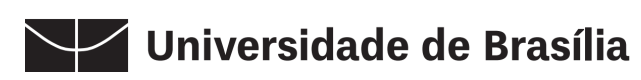
# Lista 2: Inferência estatística via simulação

**Sara Borges Lopes de Sousa** — 21250707-3

Universidade de Brasília (UnB)
Departamento de Ciência da Computação
Programa de Pós-Graduação em Computação Aplicada
Disciplina: Métodos Computacionais Intensivos para Mineração de Dados

Brasília - DF - Brasil

sara.blsousa@gmail.com

---

## 1. Observação Metodológica

Todo o desenvolvimento foi feito em Python 3 (numpy, scipy, statsmodels, pandas e matplotlib). A semente (seed) foi fixada em `np.random.default_rng(2026)` logo no início da rotina para garantir reprodutibilidade. O conjunto de dados descreve tentativas de escalada ao Monte Rainier e foi organizado exatamente como sugere o enunciado.

## 2. Preparação do ambiente

Foram carregadas as bibliotecas necessárias e definida a semente global (`seed = 2026`), garantindo a reprodutibilidade de todas as simulações realizadas.

In [2]:
import numpy as np
import pandas as pd
from scipy import optimize, stats
import statsmodels.api as sm
import matplotlib.pyplot as plt

# Semente global para reprodutibilidade de todas as simulações.
SEED = 2026
rng = np.random.default_rng(SEED)
np.random.seed(SEED)

## 3. Leitura e organização do banco de dados

Considere o modelo

$$Y_{ij} \sim \text{Poisson}(\lambda_{ij}), \qquad \lambda_{ij} = \exp(\alpha + \beta t_i),$$

em que $Y_{ij}$ representa o número de montanhistas que atingiram o cume pela rota $j$ no dia $i$, enquanto $t_i$ corresponde à temperatura média (em °C) observada no dia $i$. Nesse modelo, $\alpha$ representa o intercepto e $\beta$ quantifica o efeito da temperatura sobre o número esperado de sucessos.

O conjunto de dados provém do Kaggle (*Mount Rainier Weather and Climbing Data*, versão 3). Reproduzimos exatamente o pipeline descrito no enunciado: realizou-se a junção das bases de escaladas e meteorologia pela data, removeram-se as colunas relacionadas à porcentagem e ao nível de bateria, filtraram-se apenas os registros em que o número de tentativas era maior ou igual ao número de sucessos, excluíram-se as rotas *glacier only - no summit attempt* e *Unknown*, converteu-se a temperatura de Fahrenheit para Celsius e, por fim, agregaram-se os dados por dia e rota, somando o número de sucessos e tentativas.

In [4]:
f2c = lambda x: (x - 32) * 5/9  # Fahrenheit -> Celsius

climbing = pd.read_csv("climbing_statistics.csv")
weather = pd.read_csv("Rainier_Weather.csv")

dados = climbing.merge(weather, on="Date", how="inner")

dados = dados.loc[:,
    ~dados.columns.str.contains("Percent|Battery")]

dados = dados[
    (dados["Attempted"] >= dados["Succeeded"]) &
    (dados["Route"] != "glacier only - no summit attempt") &
    (dados["Route"] != "Unknown")
].copy()

dados["Temperatura"] = f2c(dados["Temperature AVG"])
dados["Cleaver"] = dados["Route"] == "Disappointment Cleaver"
dados["Data"] = pd.to_datetime(dados["Date"])

dados = dados.rename(columns={
    "Route": "Rota",
    "Succeeded": "Sucessos",
    "Attempted": "Tentativas"
})

# Agregação por dia e rota.
g = dados.groupby(["Data", "Rota"])
dados["Sucessos"] = g["Sucessos"].transform("sum")
dados["Tentativas"] = g["Tentativas"].transform("sum")

dados = (
    dados[
        ["Data", "Sucessos", "Rota",
         "Tentativas", "Temperatura", "Cleaver"]
    ]
    .drop_duplicates()
    .reset_index(drop=True)
)

y = dados["Sucessos"].to_numpy(dtype=float)
t = dados["Temperatura"].to_numpy(dtype=float)
cleaver = dados["Cleaver"].to_numpy(dtype=bool)

n = len(y)

print(f"Dimensão final: {dados.shape[0]} linhas x {dados.shape[1]} colunas")

Dimensão final: 466 linhas x 6 colunas


A execução do código resulta em um conjunto de dados contendo 466 observações e seis variáveis:

```
Dimensão final: 466 linhas x 6 colunas
```

## 4. Questão 1

### 4.1. a) Teste de hipóteses por simulação

Para verificar se a rota *Disappointment Cleaver* apresenta, em média, um número de sucessos diferente das demais rotas, foi realizado um teste de permutação. As hipóteses consideradas foram

$$H_0: \mu_C = \mu_O \quad \text{versus} \quad H_1: \mu_C \neq \mu_O,$$

em que $\mu_C$ representa a média de sucessos da rota *Disappointment Cleaver* e $\mu_O$ a média conjunta das demais rotas. A estatística de teste adotada foi

$$T = \bar{Y}_C - \bar{Y}_O.$$

Sob a hipótese nula, assume-se que os rótulos das rotas são permutáveis. Assim, a distribuição nula de $T$ foi obtida por meio de 50.000 permutações aleatórias dos rótulos, preservando o tamanho do grupo correspondente à rota *Disappointment Cleaver*. O p-valor bilateral foi calculado como a proporção de estatísticas simuladas cujo valor absoluto foi maior ou igual ao valor observado.

In [5]:
n_perm = 50_000

T_obs = y[cleaver].mean() - y[~cleaver].mean()

n_cl = cleaver.sum()
T_perm = np.empty(n_perm)

for b in range(n_perm):
    idx = rng.permutation(n)[:n_cl]  # grupo "Cleaver" aleatório
    mask = np.zeros(n, dtype=bool)
    mask[idx] = True

    T_perm[b] = y[mask].mean() - y[~mask].mean()

p_valor = np.mean(np.abs(T_perm) >= abs(T_obs))

print(f"Média Cleaver : {y[cleaver].mean():.4f}")
print(f"Média demais  : {y[~cleaver].mean():.4f}")
print(f"T observado   : {T_obs:.4f}")
print(f"p-valor       : {p_valor:.5f}")

Média Cleaver : 20.4888
Média demais  : 4.1701
T observado   : 16.3186
p-valor       : 0.00000


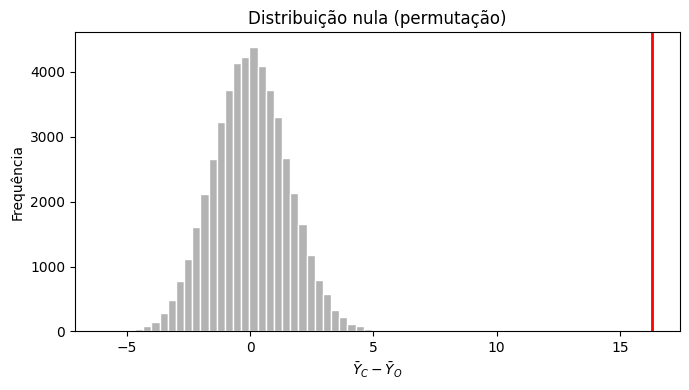

In [6]:
# Figura 1. Distribuição nula (permutação)
plt.figure(figsize=(7, 4))
plt.hist(T_perm, bins=40, color="0.7", edgecolor="white")
plt.axvline(T_obs, color="red", linewidth=2)
plt.title("Distribuição nula (permutação)")
plt.xlabel(r"$\bar{Y}_C - \bar{Y}_O$")
plt.ylabel("Frequência")
plt.tight_layout()
plt.show()

A execução do algoritmo produziu os seguintes resultados:

```
Média Cleaver : 20.4888
Média demais  : 4.1701
T observado   : 16.3186
p-valor       : 0.00000
```

Como o p-valor obtido é praticamente nulo (p < 0,0001), rejeita-se a hipótese nula ao nível de significância de 5%. Portanto, há evidências estatísticas de que a média de montanhistas que atingem o cume pela rota *Disappointment Cleaver* difere da média observada nas demais rotas, sendo significativamente maior no conjunto de dados analisado.

### 4.2. b) Estimador de máxima verossimilhança

Para modelar o número de montanhistas que atingiram o cume em função da temperatura, foi ajustado um modelo de regressão de Poisson com função de ligação logarítmica. Nesse modelo, assume-se que

$$Y_{ij} \sim \text{Poisson}(\lambda_{ij}), \qquad \lambda_{ij} = \exp(\alpha + \beta t_i),$$

cuja log-verossimilhança, desconsiderando a constante $-\sum \log(y_{ij}!)$, é dada por

$$\ell(\alpha, \beta) = \sum_{i,j} \left[ y_{ij}(\alpha + \beta t_i) - e^{\alpha + \beta t_i} \right].$$

A estimação dos parâmetros foi realizada pelo método da máxima verossimilhança, utilizando a função `minimize` do módulo `scipy.optimize`. Como essa função realiza minimização, foi otimizado o negativo da log-verossimilhança. Para verificar a implementação, os resultados foram comparados com aqueles obtidos pelo modelo linear generalizado (GLM) da biblioteca `statsmodels`, que emprega o algoritmo Iteratively Reweighted Least Squares (IRLS) e fornece, adicionalmente, os erros-padrão das estimativas.

In [7]:
def neg_loglik(par, y, t):
    eta = par[0] + par[1] * t  # preditor linear
    return -np.sum(y * eta - np.exp(eta))

aj = optimize.minimize(
    neg_loglik,
    x0=[0.0, 0.0],
    args=(y, t),
    method="BFGS"
)

alpha_hat, beta_hat = aj.x

# GLM (IRLS) para validação e erros-padrão.
X = sm.add_constant(t)
glm = sm.GLM(
    y,
    X,
    family=sm.families.Poisson()
).fit()

ep = glm.bse

print(f"alpha_hat = {alpha_hat:.5f} (ep {ep[0]:.5f})")
print(f"beta_hat  = {beta_hat:.5f} (ep {ep[1]:.5f})")
print(f"exp(beta) = {np.exp(beta_hat):.5f}")
print("Validação glm():", np.round(glm.params, 5))

alpha_hat = 1.98846 (ep 0.02108)
beta_hat  = 0.08130 (ep 0.00284)
exp(beta) = 1.08470
Validação glm(): [1.98846 0.0813 ]


A execução do código produziu as seguintes estimativas:

```
alpha_hat = 1.98846 (ep 0.02108)
beta_hat  = 0.08130 (ep 0.00284)
exp(beta) = 1.08470
Validação glm(): [1.98846 0.08130]
```

Observa-se que as estimativas obtidas pelo método de otimização numérica coincidem com aquelas produzidas pelo GLM, confirmando a correta implementação da função de log-verossimilhança. Em particular, foram obtidas as estimativas $\hat{\alpha} = 1{,}98846$ e $\hat{\beta} = 0{,}08130$.

Como o coeficiente associado à temperatura é positivo, conclui-se que temperaturas mais elevadas estão associadas a um aumento no número esperado de montanhistas que alcançam o cume. Além disso, $e^{\hat{\beta}} = 1{,}08470$, o que indica que um aumento de 1 °C na temperatura média está associado, em média, a um aumento de aproximadamente 8,47% no número esperado de sucessos, mantendo constantes os demais fatores do modelo.

### 4.3. c) Distribuição prevista a 15 °C

Com os parâmetros estimados, foi calculado o número esperado de montanhistas que atingem o cume quando a temperatura média é de 15 °C. Para isso, utilizou-se a expressão

$$\hat{\lambda}_{15} = \exp(\hat{\alpha} + \hat{\beta} \cdot 15),$$

de modo que $Y \sim \text{Poisson}(\hat{\lambda}_{15})$.

A partir desse valor, foi obtida a função de massa de probabilidade da distribuição de Poisson e determinado o intervalo central de 95% por meio dos quantis de ordem 2,5% e 97,5%.

In [8]:
lambda_15 = np.exp(alpha_hat + beta_hat * 15)

k = np.arange(0, 51)
pk = stats.poisson.pmf(k, lambda_15)

ic = stats.poisson.ppf([0.025, 0.975], lambda_15)

print(f"lambda_15 = {lambda_15:.4f}")
print(f"Intervalo central de 95%: [{ic[0]:.0f}, {ic[1]:.0f}]")

lambda_15 = 24.7292
Intervalo central de 95%: [15, 35]


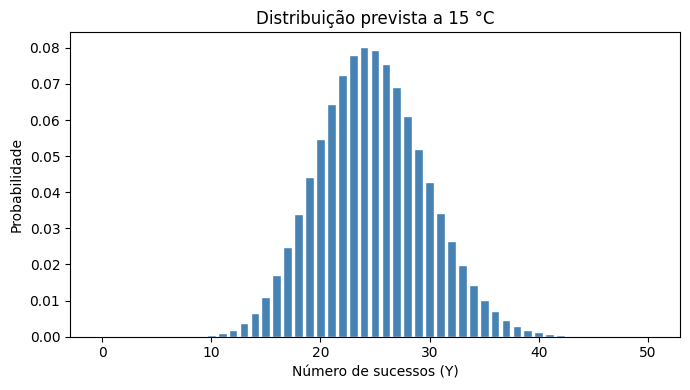

In [9]:
# Figura 2. Distribuição prevista a 15 °C
plt.figure(figsize=(7, 4))
plt.bar(k, pk, color="steelblue", edgecolor="white")
plt.title("Distribuição prevista a 15 °C")
plt.xlabel("Número de sucessos (Y)")
plt.ylabel("Probabilidade")
plt.tight_layout()
plt.show()

A execução do código forneceu os seguintes resultados:

```
lambda_15 = 24.7292
Intervalo central de 95%: [15, 35]
```

Assim, para uma temperatura média de 15 °C, o modelo estima que o número esperado de montanhistas que alcançam o cume seja de aproximadamente $\hat{\lambda}_{15} = 24{,}73$. Além disso, considerando a distribuição de Poisson ajustada, aproximadamente 95% das realizações esperadas encontram-se entre 15 e 35 sucessos. Esse resultado indica que, embora o valor médio seja de cerca de 25 montanhistas, existe variabilidade natural inerente ao processo, compatível com a distribuição de Poisson assumida pelo modelo.

#### 4.3.1. Intervalo de confiança de 95% para $e^\beta$ via bootstrap paramétrico

Para avaliar a incerteza associada à estimativa de $e^\beta$, foi empregado o método de *bootstrap* paramétrico. Inicialmente, calcularam-se as médias ajustadas pelo modelo,

$$\hat{\lambda}_i = \exp(\hat{\alpha} + \hat{\beta} t_i),$$

e, em seguida, foram geradas $B = 5\,000$ amostras sintéticas da distribuição de Poisson com essas médias. Para cada amostra simulada, os parâmetros do modelo foram novamente estimados por máxima verossimilhança e calculado o correspondente valor de $e^{\hat{\beta}^*}$. O intervalo de confiança de 95% foi obtido pelos percentis empíricos de ordem 2,5% e 97,5% da distribuição bootstrap.

In [10]:
B = 5_000

lambda_hat = np.exp(alpha_hat + beta_hat * t)

def estima_beta(y_sim):
    r = optimize.minimize(
        neg_loglik,
        [alpha_hat, beta_hat],
        args=(y_sim, t),
        method="BFGS"
    )
    return r.x[1]

boot_expbeta = np.array([
    np.exp(estima_beta(rng.poisson(lambda_hat)))
    for _ in range(B)
])

ic = np.percentile(boot_expbeta, [2.5, 97.5])

print(f"exp(beta) estimado : {np.exp(beta_hat):.4f}")
print(f"IC 95% (percentil) : [{ic[0]:.4f}, {ic[1]:.4f}]")
print(
    f"Aumento por +1 C   : {(np.exp(beta_hat)-1)*100:.2f}% "
    f"(IC {(ic[0]-1)*100:.2f}% a {(ic[1]-1)*100:.2f}%)"
)

exp(beta) estimado : 1.0847
IC 95% (percentil) : [1.0786, 1.0907]
Aumento por +1 C   : 8.47% (IC 7.86% a 9.07%)


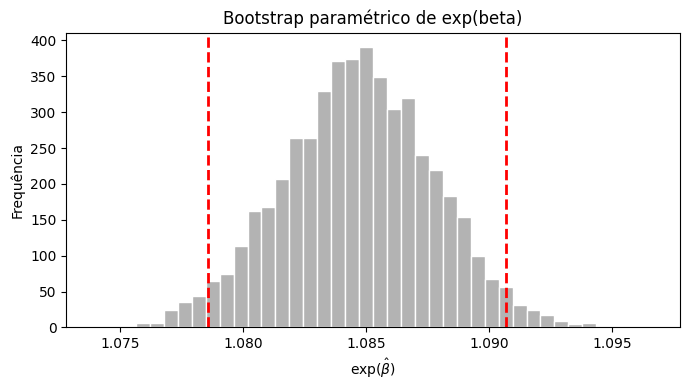

In [11]:
# Figura 3. Bootstrap paramétrico de exp(beta)
plt.figure(figsize=(7, 4))
plt.hist(boot_expbeta, bins=40, color="0.7", edgecolor="white")
plt.axvline(ic[0], color="red", linestyle="--", linewidth=2)
plt.axvline(ic[1], color="red", linestyle="--", linewidth=2)
plt.title("Bootstrap paramétrico de exp(beta)")
plt.xlabel(r"$\exp(\hat{\beta})$")
plt.ylabel("Frequência")
plt.tight_layout()
plt.show()

A execução do procedimento produziu os seguintes resultados:

```
exp(beta) estimado : 1.0847
IC 95% (percentil) : [1.0786, 1.0907]
Aumento por +1 C   : 8.47% (IC 7.86% a 9.07%)
```

O parâmetro $e^\beta$ representa o fator multiplicativo da média esperada do número de montanhistas que atingem o cume para cada aumento de 1 °C na temperatura média. A estimativa obtida foi $e^{\hat{\beta}} = 1{,}0847$, com intervalo de confiança bootstrap de 95% de $[1{,}0786,\ 1{,}0907]$.

Em termos práticos, isso significa que um aumento de 1 °C na temperatura está associado a um incremento médio de aproximadamente **8,47%** no número esperado de montanhistas que alcançam o cume, com intervalo de confiança variando de **7,86%** a **9,07%**. Como todo o intervalo de confiança está acima de 1, conclui-se que o efeito da temperatura é positivo e estatisticamente significativo, indicando uma associação consistente entre temperaturas mais elevadas e um maior número esperado de sucessos nas escaladas.

### 4.4. e) Diagnóstico do modelo via simulação

#### 4.4.1. Avaliação do ajuste do modelo por simulação

Para avaliar a qualidade do ajuste do modelo de Poisson, foi realizado um estudo de simulação paramétrica. Inicialmente, calculou-se o erro quadrático médio (MSE) observado nos dados originais,

$$\text{MSE} = \frac{1}{n} \sum_{i=1}^n (y_i - \hat{\lambda}_i)^2,$$

em que $\hat{\lambda}_i = \exp(\hat{\alpha} + \hat{\beta} t_i)$. Em seguida, foram gerados 10.000 conjuntos de dados sintéticos a partir do modelo ajustado. Para cada conjunto simulado, o modelo foi novamente ajustado por máxima verossimilhança e o respectivo MSE foi calculado. Por fim, comparou-se o MSE observado com a distribuição empírica dos MSEs obtidos nas simulações.

In [12]:
def mse(y_obs, a, b):
    return np.mean((y_obs - np.exp(a + b * t))**2)

mse_obs = mse(y, alpha_hat, beta_hat)

M = 10_000
mse_sim = np.empty(M)

for i in range(M):
    y_sim = rng.poisson(lambda_hat)

    r = optimize.minimize(
        neg_loglik,
        [alpha_hat, beta_hat],
        args=(y_sim, t),
        method="BFGS"
    )

    mse_sim[i] = mse(y_sim, r.x[0], r.x[1])

p_mse = np.mean(mse_sim >= mse_obs)

print(f"MSE observado      : {mse_obs:.3f}")
print(f"MSE médio (sim.)   : {mse_sim.mean():.3f}")
print(f"MSE mediano (sim.) : {np.median(mse_sim):.3f}")
print(f"P(MSE_sim >= obs)  : {p_mse}")

MSE observado      : 238.823
MSE médio (sim.)   : 10.355
MSE mediano (sim.) : 10.339
P(MSE_sim >= obs)  : 0.0


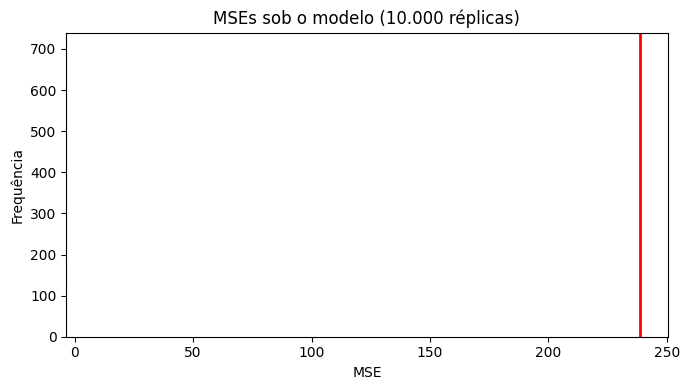

In [13]:
# Figura 4. Diagnóstico MSE
plt.figure(figsize=(7, 4))
plt.hist(mse_sim, bins=40, color="0.7", edgecolor="white")
plt.axvline(mse_obs, color="red", linewidth=2)
plt.title("MSEs sob o modelo (10.000 réplicas)")
plt.xlabel("MSE")
plt.ylabel("Frequência")
plt.tight_layout()
plt.show()

A execução do procedimento resultou nos seguintes valores:

```
MSE observado      : 238.823
MSE médio (sim.)   : 10.355
MSE mediano (sim.) : 10.339
P(MSE_sim >= obs)  : 0.0
```

Observa-se que o erro quadrático médio calculado a partir dos dados observados (MSE = 238,823) é muito superior aos valores obtidos nas simulações sob o modelo de Poisson, cuja distribuição está concentrada em torno de 10,35. Além disso, nenhuma das 10.000 réplicas apresentou um MSE igual ou superior ao observado, resultando em uma probabilidade empírica praticamente nula.

Esse resultado fornece fortes evidências de que o modelo de Poisson ajustado não descreve adequadamente os dados. Em particular, verifica-se a presença de **superdispersão**, isto é, a variância observada excede substancialmente a variância prevista pelo modelo, que assume igualdade entre média e variância. Uma explicação plausível para esse comportamento é a elevada heterogeneidade existente entre as diferentes rotas de escalada, evidenciada no teste de permutação realizado anteriormente, bem como a ausência de variáveis explicativas importantes, como velocidade do vento, umidade relativa do ar, precipitação e radiação solar.

Dessa forma, modelos mais flexíveis, como a regressão Binomial Negativa, ou a inclusão da variável categórica correspondente à rota de escalada e de outras covariáveis relevantes, tendem a proporcionar um ajuste significativamente superior ao obtido pelo modelo de Poisson considerado neste estudo.

## 5. Questão 2: Volume da elipsoide por Monte Carlo

### 5.0.1. Estimativa do volume de uma elipsoide por Monte Carlo

Considere a superfície

$$\frac{x^2}{2} + \frac{y^2}{3} + \frac{z^2}{4} = 1,$$

que representa uma elipsoide com semieixos $a = \sqrt{2}$, $b = \sqrt{3}$, $c = 2$.

O volume dessa elipsoide foi estimado por integração de Monte Carlo. Para isso, foram gerados $N = 2\,000\,000$ pontos uniformemente distribuídos na caixa retangular que circunscreve a elipsoide, $[-a, a] \times [-b, b] \times [-c, c]$.

A estimativa do volume é obtida multiplicando-se o volume da caixa pela proporção de pontos que pertencem ao interior da elipsoide. Para fins de comparação, utilizou-se também o valor analítico do volume,

$$V = \frac{4}{3}\pi a b c.$$

In [14]:
N = 2_000_000

a, b, c = np.sqrt(2), np.sqrt(3), 2.0

vol_caixa = (2*a) * (2*b) * (2*c)

x = rng.uniform(-a, a, N)
y_ = rng.uniform(-b, b, N)
z = rng.uniform(-c, c, N)

dentro = (x**2/2 + y_**2/3 + z**2/4) <= 1

p_dentro = dentro.mean()

vol_mc = p_dentro * vol_caixa

ep_mc = vol_caixa * np.sqrt(
    p_dentro * (1 - p_dentro) / N
)

vol_exato = 4/3 * np.pi * a * b * c

print(f"Volume (Monte Carlo) : {vol_mc:.4f}")
print(f"Erro-padrão MC       : {ep_mc:.4f}")
print(f"Volume exato         : {vol_exato:.4f}")

Volume (Monte Carlo) : 20.5237
Erro-padrão MC       : 0.0138
Volume exato         : 20.5208


A execução do algoritmo produziu os seguintes resultados:

```
Volume (Monte Carlo) : 20.5237
Erro-padrão MC       : 0.0138
Volume exato         : 20.5208
```

Observa-se que a estimativa obtida pelo método de Monte Carlo foi de aproximadamente 20,5237, valor extremamente próximo do volume analítico da elipsoide, $V = \frac{4}{3}\pi\sqrt{2}\sqrt{3}\cdot 2 \approx 20{,}5208$.

Além disso, o erro-padrão da estimativa foi de apenas 0,0138, indicando elevada precisão. A diferença entre o valor estimado e o valor exato é inferior ao erro esperado pelo método de Monte Carlo, evidenciando a consistência do procedimento de simulação. Esse resultado demonstra que, com um número suficientemente grande de amostras, a integração por Monte Carlo fornece aproximações altamente precisas para volumes de regiões tridimensionais, mesmo quando sua geometria é relativamente complexa.

## 6. Uso de LLMs e reprodutibilidade

O NotebookLM e o Gemini foram utilizados como ferramentas de apoio para: revisão textual e formatação do relatório, incluindo a estrutura das seções, a padronização de tabelas e as legendas das figuras.

Todos os resultados podem ser reproduzidos executando os blocos de código na ordem em que aparecem, com numpy e matplotlib. A semente global foi fixada em `np.random.default_rng(2026)`.

### Referências

1. RIZZO, M. L. *Statistical Computing with R*. Boca Raton: CRC Press, 2007.
2. ROBERT, C. P.; CASELLA, G. *Introducing Monte Carlo Methods with R*. New York: Springer, 2010.
3. DAVISON, A. C.; HINKLEY, D. V. *Bootstrap Methods and Their Application*. Cambridge: Cambridge University Press, 1997.
4. EFRON, B.; TIBSHIRANI, R. J. *An Introduction to the Bootstrap*. Boca Raton: Chapman & Hall/CRC, 1993.
5. McCULLAGH, P.; NELDER, J. A. *Generalized Linear Models*. 2. ed. London: Chapman & Hall, 1989.
6. ROBERT, C. P.; CASELLA, G. *Monte Carlo Statistical Methods*. 2. ed. New York: Springer, 2004.
7. HARRIS, C. R. et al. Array programming with NumPy. *Nature*, v. 585, p. 357–362, 2020.
8. VIRTANEN, P. et al. SciPy 1.0: fundamental algorithms for scientific computing in Python. *Nature Methods*, v. 17, p. 261–272, 2020.
9. SEABOLD, S.; PERKTOLD, J. statsmodels: Econometric and Statistical Modeling with Python. In: *Proceedings of the 9th Python in Science Conference*. 2010.
10. CODERSREE. Mount Rainier Weather and Climbing Data (v3). Kaggle, 2018. Disponível em: https://www.kaggle.com/codersree/mount-rainier-weather-and-climbing-data. Acesso em: 02 jul. 2026.